In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

# For statistical analysis
import scipy.stats as stats
from scipy.stats import f_oneway, ttest_ind
import statsmodels.api as sm
from statsmodels.formula.api import ols

# For machine learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb

# For explainability
import shap

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Load the dataset from Hugging Face
print("Loading dataset from Hugging Face...")
dataset = load_dataset("lukebarousse/data_jobs")

# Convert to pandas DataFrame
df = pd.DataFrame(dataset['train'])

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Loading dataset from Hugging Face...
Dataset loaded successfully!
Shape: (785741, 17)

First few rows:


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


In [ ]:
# Explore dataset structure
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Rows: {df.shape[0]:,}")
print(f"Number of Columns: {df.shape[1]}")
print(f"\nColumn Names:")
print(df.columns.tolist())
print(f"\nData Types:")
print(df.dtypes)


Dataset Shape: (785741, 17)
Number of Rows: 785,741
Number of Columns: 17

Column Names:
['job_title_short', 'job_title', 'job_location', 'job_via', 'job_schedule_type', 'job_work_from_home', 'search_location', 'job_posted_date', 'job_no_degree_mention', 'job_health_insurance', 'job_country', 'salary_rate', 'salary_year_avg', 'salary_hour_avg', 'company_name', 'job_skills', 'job_type_skills']

Data Types:
job_title_short           object
job_title                 object
job_location              object
job_via                   object
job_schedule_type         object
job_work_from_home          bool
search_location           object
job_posted_date           object
job_no_degree_mention       bool
job_health_insurance        bool
job_country               object
salary_rate               object
salary_year_avg          float64
salary_hour_avg          float64
company_name              object
job_skills                object
job_type_skills           object
dtype: object


In [ ]:
# Check missing values and data quality
missing_stats = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_stats = missing_stats[missing_stats['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
print(missing_stats.to_string(index=False))

print(df.describe())

           Column  Missing_Count  Missing_Percentage
  salary_hour_avg         775079               98.64
  salary_year_avg         763738               97.20
      salary_rate         752674               95.79
  job_type_skills         117037               14.90
       job_skills         117037               14.90
job_schedule_type          12667                1.61
     job_location           1045                0.13
      job_country             49                0.01
        job_title              1                0.00
          job_via              8                0.00
     company_name             18                0.00
       salary_year_avg  salary_hour_avg
count     22003.000000     10662.000000
mean     123286.274072        47.016598
std       48312.449482        21.890738
min       15000.000000         8.000000
25%       90000.000000        27.500000
50%      115000.000000        45.980000
75%      150000.000000        61.159996
max      960000.000000       391.000000


In [ ]:
# Create a copy for preprocessing
df_processed = df.copy()

# Step 1: Filter for 2023 data only
if 'job_posted_date' in df_processed.columns:
    df_processed['job_posted_date'] = pd.to_datetime(df_processed['job_posted_date'], errors='coerce')
    df_processed['year'] = df_processed['job_posted_date'].dt.year
    df_2023 = df_processed[df_processed['year'] == 2023].copy()
    print(f"Filtered for 2023 data: {len(df_2023):,} rows")
else:
    df_2023 = df_processed.copy()
    print(f"No date filtering applied: {len(df_2023):,} rows")

# Step 2: Handle salary-related columns
# Identify salary columns
salary_columns = [col for col in df_2023.columns if 'salary' in col.lower()]
print(f"\nSalary columns found: {salary_columns}")

# Create unified salary column if multiple salary columns exist
if 'salary_year_avg' in df_2023.columns:
    df_2023['salary'] = df_2023['salary_year_avg']
elif 'salary_yearly' in df_2023.columns:
    df_2023['salary'] = df_2023['salary_yearly']
elif len(salary_columns) > 0:
    df_2023['salary'] = df_2023[salary_columns[0]]
else:
    print("Warning: No salary column found, creating placeholder")
    df_2023['salary'] = np.nan

# Remove rows with missing or zero salaries
df_2023 = df_2023[df_2023['salary'].notna()]
df_2023 = df_2023[df_2023['salary'] > 0]
print(f"After removing missing/zero salaries: {len(df_2023):,} rows")

print(f"\nFinal dataset shape: {df_2023.shape}")
print(f"\nSalary Statistics:")
print(df_2023['salary'].describe())

Filtered for 2023 data: 785,741 rows

Salary columns found: ['salary_rate', 'salary_year_avg', 'salary_hour_avg']
After removing missing/zero salaries: 22,003 rows

Final dataset shape: (22003, 19)

Salary Statistics:
count     22003.000000
mean     123286.274072
std       48312.449482
min       15000.000000
25%       90000.000000
50%      115000.000000
75%      150000.000000
max      960000.000000
Name: salary, dtype: float64


In [ ]:
# Step 3: Process categorical variables
# Identify key categorical columns
categorical_cols = []

# Remote status
if 'job_work_from_home' in df_2023.columns:
    df_2023['remote_status'] = df_2023['job_work_from_home'].fillna(False).astype(str)
    categorical_cols.append('remote_status')
    print(f"Remote status processed")
    print(f"  Distribution:\n{df_2023['remote_status'].value_counts()}\n")

# Schedule type
if 'job_schedule_type' in df_2023.columns:
    df_2023['schedule_type'] = df_2023['job_schedule_type'].fillna('Unknown')
    categorical_cols.append('schedule_type')
    print(f"Schedule type processed")
    print(f"  Distribution:\n{df_2023['schedule_type'].value_counts()}\n")

# Country
if 'job_country' in df_2023.columns:
    df_2023['country'] = df_2023['job_country'].fillna('Unknown')
    # Keep only top countries (with at least 50 jobs)
    country_counts = df_2023['country'].value_counts()
    top_countries = country_counts[country_counts >= 50].index.tolist()
    df_2023['country'] = df_2023['country'].apply(lambda x: x if x in top_countries else 'Other')
    categorical_cols.append('country')
    print(f"Country processed (keeping countries with ≥50 jobs)")
    print(f"  Distribution:\n{df_2023['country'].value_counts()}\n")

# Job title/role
if 'job_title_short' in df_2023.columns:
    df_2023['job_role'] = df_2023['job_title_short'].fillna('Unknown')
    categorical_cols.append('job_role')
    print(f"Job role processed")
    print(f"  Distribution:\n{df_2023['job_role'].value_counts()}\n")
elif 'job_title' in df_2023.columns:
    df_2023['job_role'] = df_2023['job_title'].fillna('Unknown')
    categorical_cols.append('job_role')

print(f"Total categorical columns identified: {len(categorical_cols)}")
print(f"  Columns: {categorical_cols}")

Remote status processed
  Distribution:
remote_status
False    18724
True      3279
Name: count, dtype: int64

Schedule type processed
  Distribution:
schedule_type
Full-time                                21018
Contractor                                 398
Full-time and Part-time                    336
Part-time                                   69
Full-time and Contractor                    50
Internship                                  27
Full-time and Temp work                     26
Unknown                                     16
Temp work                                   14
Full-time and Internship                    11
Full-time, Part-time, and Internship         9
Contractor and Temp work                     6
Full-time, Contractor, and Temp work         5
Full-time, Part-time, and Contractor         3
Part-time and Contractor                     3
Full-time, Contractor, and Internship        3
Internship and Full-time                     2
Full-time and Per diem              

In [ ]:
# Step 4: Process skills data
# Find skills columns
skills_cols = [col for col in df_2023.columns if 'skill' in col.lower()]
print(f"Skills columns found: {skills_cols}\n")

# Initialize skills dictionary
all_skills = set()
skills_by_job = []

# Check if there's a job_skills column
if 'job_skills' in df_2023.columns:
    print("Processing job_skills column...")
    for idx, skills in df_2023['job_skills'].items():
        if pd.notna(skills):
            if isinstance(skills, str):
                # Parse string representation of list
                skills_list = eval(skills) if skills.startswith('[') else [s.strip() for s in skills.split(',')]
            elif isinstance(skills, list):
                skills_list = skills
            else:
                skills_list = []

            skills_list = [s.lower().strip() for s in skills_list if s]
            skills_by_job.append(skills_list)
            all_skills.update(skills_list)
        else:
            skills_by_job.append([])

    df_2023['skills_list'] = skills_by_job
    print(f"Skills extracted: {len(all_skills)} unique skills")

    # Create binary columns for common skills (appearing in at least 5% of jobs)
    min_skill_count = len(df_2023) * 0.05
    skill_counts = {}
    for skills in skills_by_job:
        for skill in skills:
            skill_counts[skill] = skill_counts.get(skill, 0) + 1

    common_skills = [skill for skill, count in skill_counts.items() if count >= min_skill_count]
    common_skills = sorted(common_skills, key=lambda x: skill_counts[x], reverse=True)[:30]  # Top 30 skills

    print(f"Common skills (appearing in ≥5% of jobs, top 30): {len(common_skills)}")
    print(f"  Top skills: {common_skills[:10]}")

    # Create binary indicators for each common skill
    for skill in common_skills:
        df_2023[f'skill_{skill}'] = df_2023['skills_list'].apply(lambda x: 1 if skill in x else 0)

    # Count total skills per job
    df_2023['num_skills'] = df_2023['skills_list'].apply(len)
    print(f"\nCreated {len(common_skills)} skill indicator columns")
    print(f"Average skills per job: {df_2023['num_skills'].mean():.1f}")
else:
    print("No job_skills column found. Creating placeholder.")
    df_2023['skills_list'] = [[] for _ in range(len(df_2023))]
    df_2023['num_skills'] = 0
    common_skills = []

print(f"\nSkills per job distribution:")
print(df_2023['num_skills'].describe())

Skills columns found: ['job_skills', 'job_type_skills']

Processing job_skills column...
Skills extracted: 219 unique skills
Common skills (appearing in ≥5% of jobs, top 30): 26
  Top skills: ['sql', 'python', 'r', 'aws', 'tableau', 'spark', 'excel', 'azure', 'sas', 'java']

Created 26 skill indicator columns
Average skills per job: 5.4

Skills per job distribution:
count    22003.000000
mean         5.403172
std          4.061289
min          0.000000
25%          3.000000
50%          5.000000
75%          8.000000
max         40.000000
Name: num_skills, dtype: float64


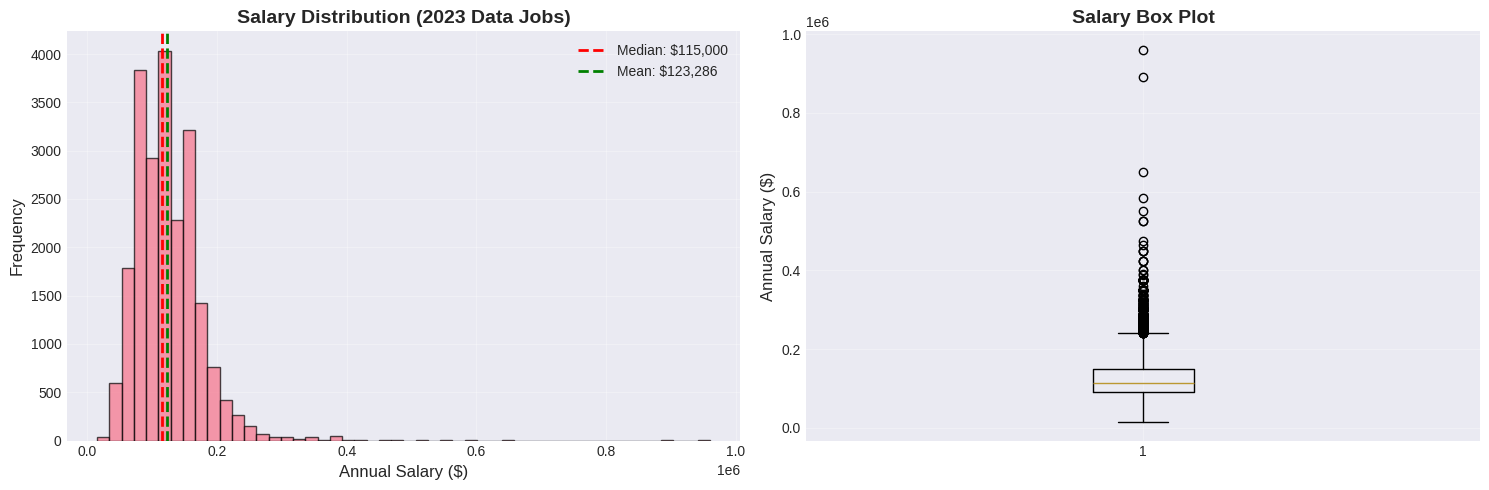

Salary Statistics:
  Mean: $123,286
  Median: $115,000
  Std Dev: $48,312
  Min: $15,000
  Max: $960,000


In [ ]:
# Salary distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df_2023['salary'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df_2023['salary'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: ${df_2023["salary"].median():,.0f}')
axes[0].axvline(df_2023['salary'].mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: ${df_2023["salary"].mean():,.0f}')
axes[0].set_xlabel('Annual Salary ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Salary Distribution (2023 Data Jobs)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(df_2023['salary'], vert=True)
axes[1].set_ylabel('Annual Salary ($)', fontsize=12)
axes[1].set_title('Salary Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Salary Statistics:")
print(f"  Mean: ${df_2023['salary'].mean():,.0f}")
print(f"  Median: ${df_2023['salary'].median():,.0f}")
print(f"  Std Dev: ${df_2023['salary'].std():,.0f}")
print(f"  Min: ${df_2023['salary'].min():,.0f}")
print(f"  Max: ${df_2023['salary'].max():,.0f}")

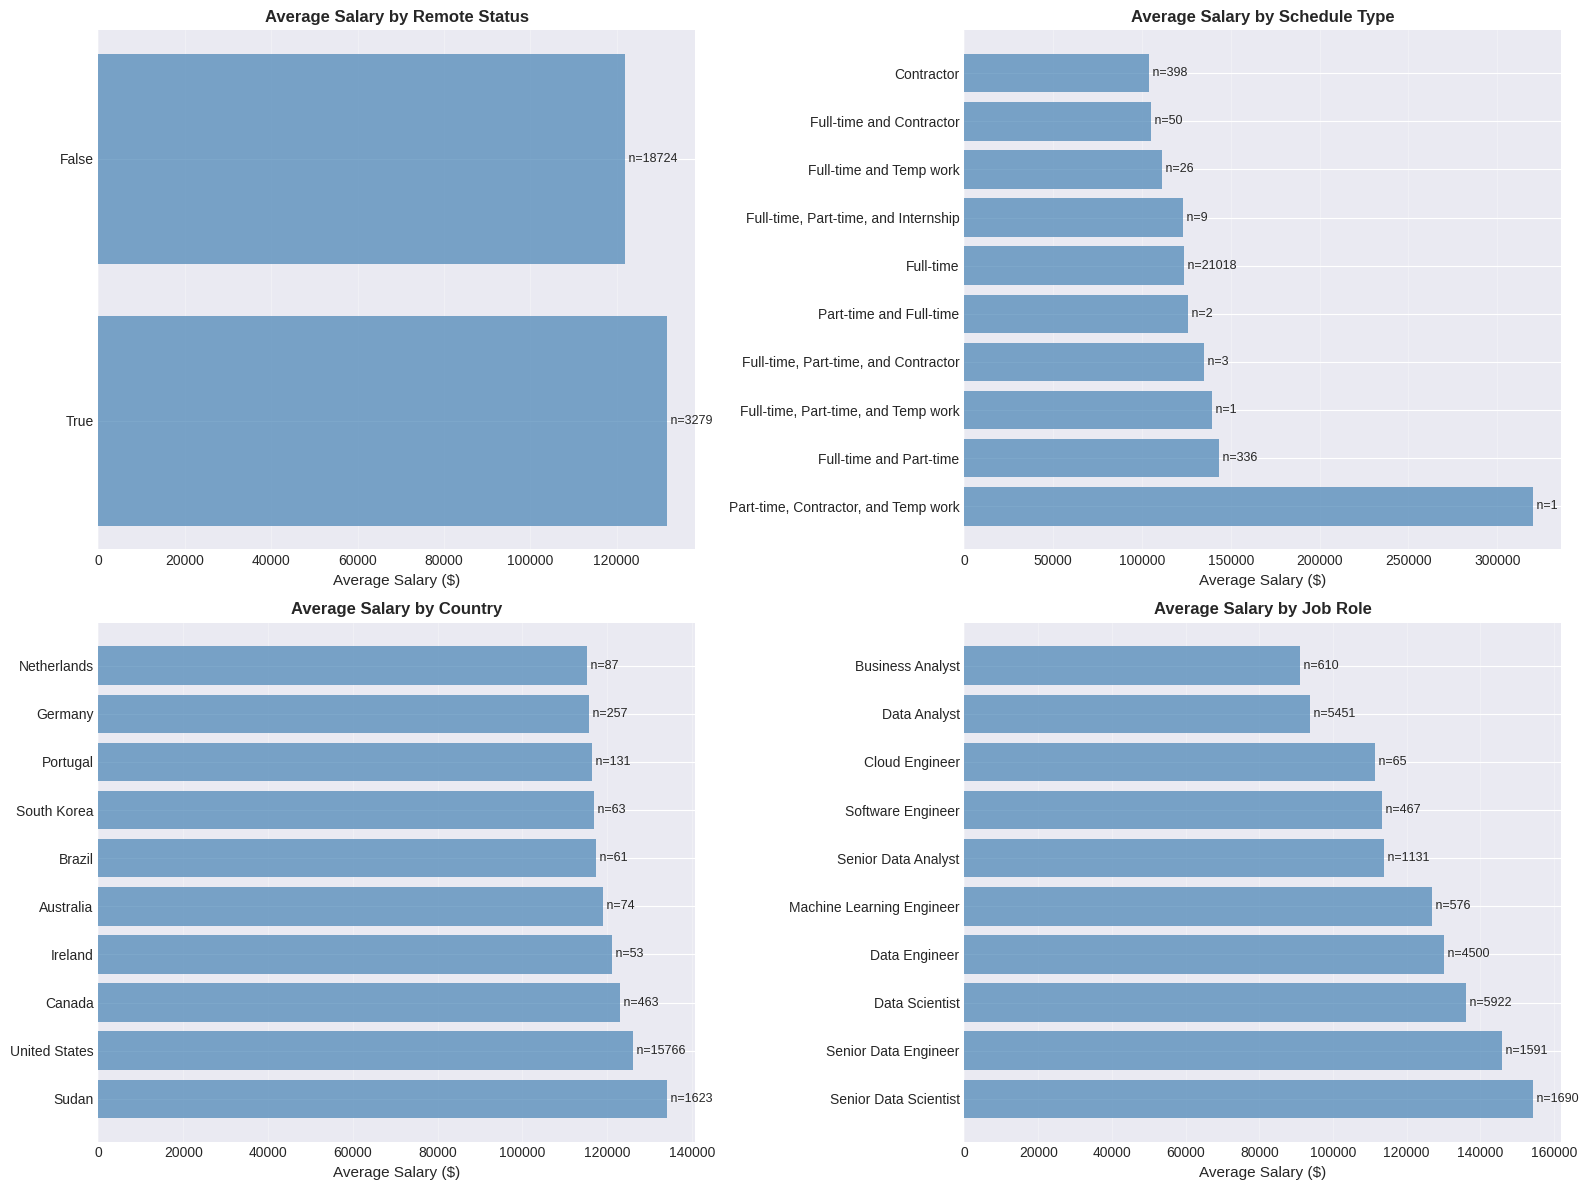

In [ ]:
# Visualize categorical variables vs salary
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

plot_idx = 0

# Plot for each categorical variable
for col in categorical_cols[:4]:  # Plot first 4 categorical variables
    if col in df_2023.columns:
        # Calculate mean salary by category
        salary_by_cat = df_2023.groupby(col)['salary'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)

        # Plot only if there are categories to show
        if len(salary_by_cat) > 0:
            # Limit to top 10 categories for readability
            salary_by_cat_top = salary_by_cat.head(10)

            x_pos = np.arange(len(salary_by_cat_top))
            axes[plot_idx].barh(x_pos, salary_by_cat_top['mean'], alpha=0.7, color='steelblue')
            axes[plot_idx].set_yticks(x_pos)
            axes[plot_idx].set_yticklabels(salary_by_cat_top.index)
            axes[plot_idx].set_xlabel('Average Salary ($)', fontsize=11)
            axes[plot_idx].set_title(f'Average Salary by {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
            axes[plot_idx].grid(axis='x', alpha=0.3)

            # Add count labels
            for i, (idx, row) in enumerate(salary_by_cat_top.iterrows()):
                axes[plot_idx].text(row['mean'], i, f" n={int(row['count'])}", va='center', fontsize=9)

            plot_idx += 1

# Remove unused subplots
for idx in range(plot_idx, 4):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

STATISTICAL ANALYSIS: JOB ATTRIBUTES IMPACT ON SALARY
ATTRIBUTE: REMOTE_STATUS

Descriptive Statistics:
               count       mean     median       std
remote_status                                       
False          18724  121830.02  115000.00  48211.51
True            3279  131601.90  128829.62  48053.85

ANOVA Test:
  F-statistic: 114.7455
  P-value: 1.0413e-26
  Significant: Yes
  Effect size (η²): 0.0052
  Effect interpretation: Negligible
ATTRIBUTE: SCHEDULE_TYPE

Descriptive Statistics:
                                       count       mean     median        std
schedule_type                                                                
Contractor                               398  103662.18  102250.00   34310.61
Contractor and Temp work                   6   86471.60   82500.00   23164.81
Full-time                              21018  123645.18  115000.00   48328.76
Full-time and Contractor                  50  104875.05  105000.00   34000.92
Full-time and Internship 

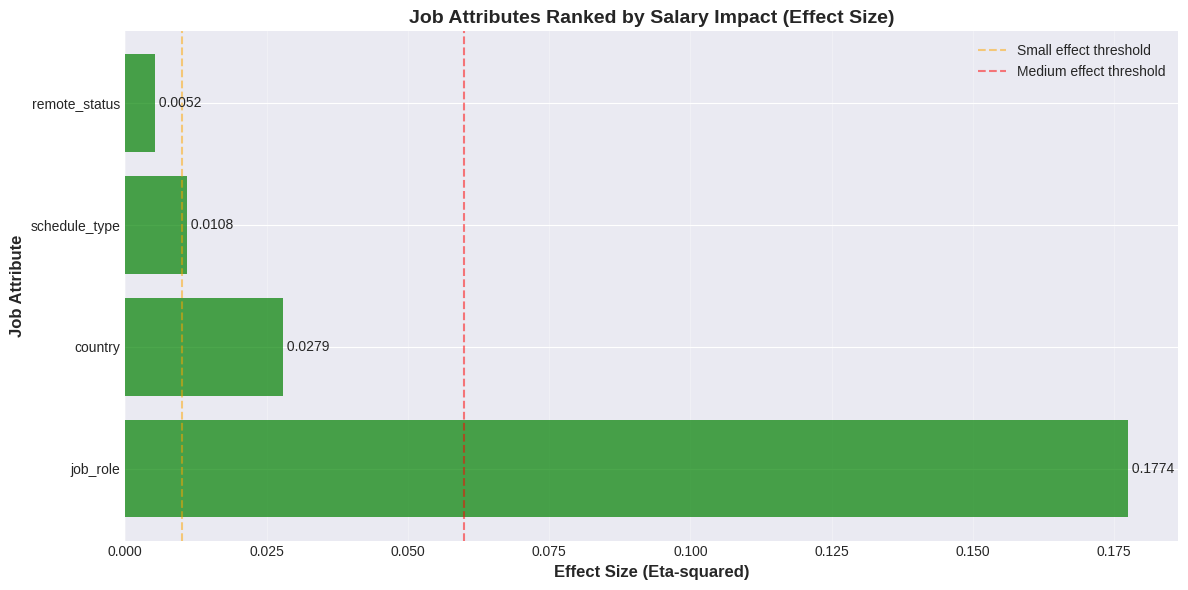

In [ ]:
# Statistical analysis of job attributes impact on salary
print("STATISTICAL ANALYSIS: JOB ATTRIBUTES IMPACT ON SALARY")

attribute_results = []

# Analyze each categorical attribute
for attr in categorical_cols:
    if attr in df_2023.columns:
        print(f"ATTRIBUTE: {attr.upper()}")

        # Group statistics
        grouped = df_2023.groupby(attr)['salary'].agg([
            ('count', 'count'),
            ('mean', 'mean'),
            ('median', 'median'),
            ('std', 'std')
        ]).round(2)

        print(f"\nDescriptive Statistics:")
        print(grouped.to_string())

        # ANOVA test (if more than 2 categories)
        categories = df_2023[attr].unique()
        if len(categories) >= 2:
            groups = [df_2023[df_2023[attr] == cat]['salary'].values for cat in categories]
            # Filter out empty groups
            groups = [g for g in groups if len(g) > 0]

            if len(groups) >= 2:
                f_stat, p_value = f_oneway(*groups)
                print(f"\nANOVA Test:")
                print(f"  F-statistic: {f_stat:.4f}")
                print(f"  P-value: {p_value:.4e}")
                print(f"  Significant: {'Yes' if p_value < 0.05 else 'No ✗'}")

                # Effect size (Eta squared)
                grand_mean = df_2023['salary'].mean()
                ss_between = sum([len(df_2023[df_2023[attr] == cat]) *
                                 (df_2023[df_2023[attr] == cat]['salary'].mean() - grand_mean)**2
                                 for cat in categories])
                ss_total = sum((df_2023['salary'] - grand_mean)**2)
                eta_squared = ss_between / ss_total if ss_total > 0 else 0

                print(f"  Effect size (η²): {eta_squared:.4f}")

                # Interpret effect size
                if eta_squared < 0.01:
                    effect_interpretation = "Negligible"
                elif eta_squared < 0.06:
                    effect_interpretation = "Small"
                elif eta_squared < 0.14:
                    effect_interpretation = "Medium"
                else:
                    effect_interpretation = "Large"
                print(f"  Effect interpretation: {effect_interpretation}")

                # Store results
                attribute_results.append({
                    'Attribute': attr,
                    'F-statistic': f_stat,
                    'P-value': p_value,
                    'Eta-squared': eta_squared,
                    'Effect_Size': effect_interpretation,
                    'Significant': p_value < 0.05
                })

print("RANKING ATTRIBUTES BY EFFECT SIZE")
# Create summary DataFrame
results_df = pd.DataFrame(attribute_results).sort_values('Eta-squared', ascending=False)
print(results_df.to_string(index=False))

# Visualize effect sizes
if len(results_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['green' if sig else 'gray' for sig in results_df['Significant']]
    bars = ax.barh(results_df['Attribute'], results_df['Eta-squared'], color=colors, alpha=0.7)
    ax.set_xlabel('Effect Size (Eta-squared)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Job Attribute', fontsize=12, fontweight='bold')
    ax.set_title('Job Attributes Ranked by Salary Impact (Effect Size)', fontsize=14, fontweight='bold')
    ax.axvline(0.01, color='orange', linestyle='--', alpha=0.5, label='Small effect threshold')
    ax.axvline(0.06, color='red', linestyle='--', alpha=0.5, label='Medium effect threshold')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)

    # Add value labels
    for i, (idx, row) in enumerate(results_df.iterrows()):
        ax.text(row['Eta-squared'], i, f" {row['Eta-squared']:.4f}", va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

INDIVIDUAL SKILLS ANALYSIS

Top 15 Skills by Salary Premium:
     Skill  Count Salary_With Premium_$ Premium_% P-value  Significant
     scala   1905    $144,998   $23,770     19.6%  0.0000         True
     kafka   1634    $144,475   $22,889     18.8%  0.0000         True
     spark   4016    $141,592   $22,393     18.8%  0.0000         True
    python  12869    $132,409   $21,976     19.9%  0.0000         True
   airflow   1497    $142,256   $20,355     16.7%  0.0000         True
tensorflow   1226    $142,459   $20,304     16.6%  0.0000         True
  redshift   1511    $140,419   $18,396     15.1%  0.0000         True
       aws   4949    $136,372   $16,883     14.1%  0.0000         True
    hadoop   2264    $138,388   $16,834     13.8%  0.0000         True
 snowflake   2455    $137,722   $16,249     13.4%  0.0000         True
     nosql   1677    $136,874   $14,709     12.0%  0.0000         True
      java   2756    $136,098   $14,646     12.1%  0.0000         True
        go   139

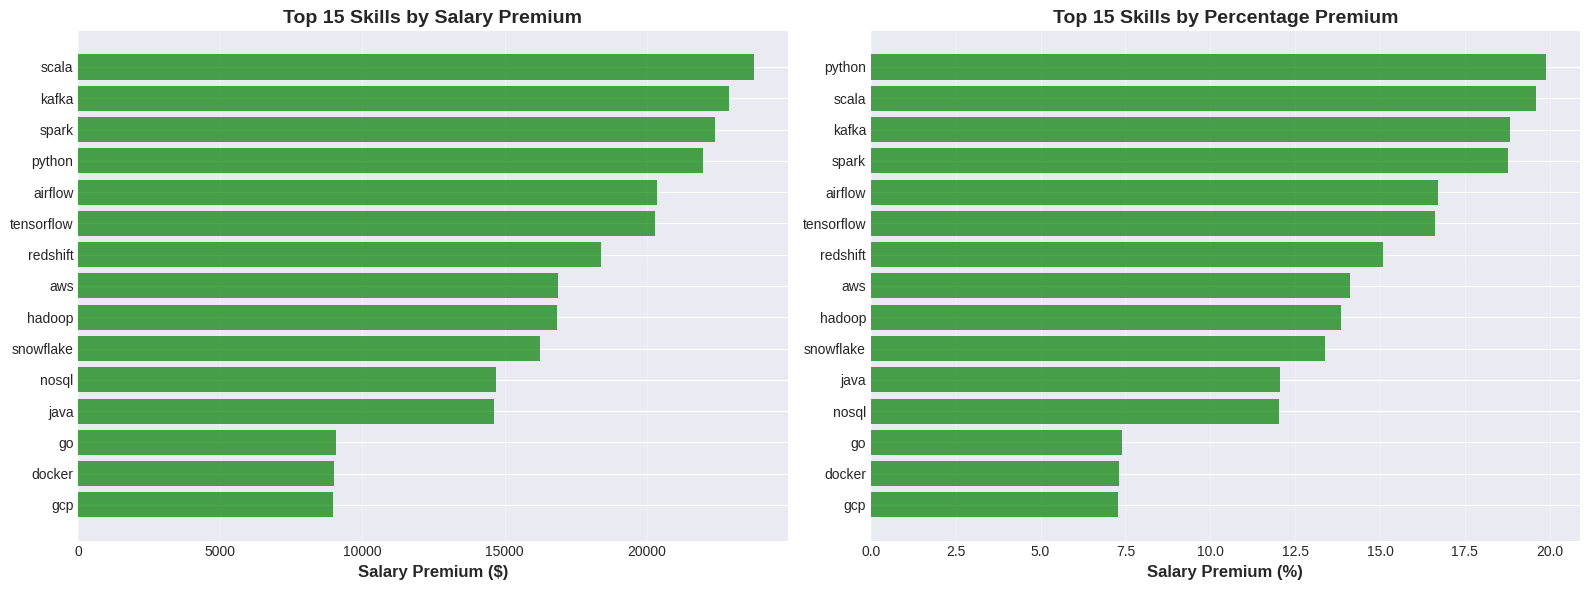


Skills analysis saved to 'skills_salary_analysis.csv'


In [ ]:
# Analyze individual skills impact on salary
print("INDIVIDUAL SKILLS ANALYSIS")
if len(common_skills) > 0:
    skill_impacts = []

    for skill in common_skills:
        skill_col = f'skill_{skill}'
        if skill_col in df_2023.columns:
            # Compare salary with and without skill
            with_skill = df_2023[df_2023[skill_col] == 1]['salary']
            without_skill = df_2023[df_2023[skill_col] == 0]['salary']

            if len(with_skill) > 0 and len(without_skill) > 0:
                # Calculate statistics
                mean_with = with_skill.mean()
                mean_without = without_skill.mean()
                premium = mean_with - mean_without
                premium_pct = (premium / mean_without) * 100

                # T-test
                t_stat, p_value = ttest_ind(with_skill, without_skill)

                # Cohen's d (effect size)
                pooled_std = np.sqrt(((len(with_skill)-1)*with_skill.std()**2 +
                                     (len(without_skill)-1)*without_skill.std()**2) /
                                    (len(with_skill) + len(without_skill) - 2))
                cohens_d = (mean_with - mean_without) / pooled_std if pooled_std > 0 else 0

                skill_impacts.append({
                    'Skill': skill,
                    'Count': len(with_skill),
                    'Salary_With': mean_with,
                    'Salary_Without': mean_without,
                    'Premium_$': premium,
                    'Premium_%': premium_pct,
                    'P-value': p_value,
                    'Cohens_d': cohens_d,
                    'Significant': p_value < 0.05
                })

    # Create DataFrame and sort by premium
    skills_df = pd.DataFrame(skill_impacts).sort_values('Premium_$', ascending=False)

    print(f"\nTop 15 Skills by Salary Premium:")
    print("="*80)
    display_cols = ['Skill', 'Count', 'Salary_With', 'Premium_$', 'Premium_%', 'P-value', 'Significant']
    top_skills = skills_df.head(15)[display_cols].copy()
    top_skills['Salary_With'] = top_skills['Salary_With'].apply(lambda x: f'${x:,.0f}')
    top_skills['Premium_$'] = top_skills['Premium_$'].apply(lambda x: f'${x:,.0f}')
    top_skills['Premium_%'] = top_skills['Premium_%'].apply(lambda x: f'{x:.1f}%')
    top_skills['P-value'] = top_skills['P-value'].apply(lambda x: f'{x:.4f}')
    print(top_skills.to_string(index=False))

    # Visualize top skills by premium
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Top 15 skills by absolute premium
    top_15 = skills_df.head(15)
    colors_sig = ['green' if sig else 'gray' for sig in top_15['Significant']]
    axes[0].barh(range(len(top_15)), top_15['Premium_$'], color=colors_sig, alpha=0.7)
    axes[0].set_yticks(range(len(top_15)))
    axes[0].set_yticklabels(top_15['Skill'])
    axes[0].set_xlabel('Salary Premium ($)', fontsize=12, fontweight='bold')
    axes[0].set_title('Top 15 Skills by Salary Premium', fontsize=14, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    axes[0].invert_yaxis()

    # Top 15 skills by percentage premium
    top_15_pct = skills_df.sort_values('Premium_%', ascending=False).head(15)
    colors_sig_pct = ['green' if sig else 'gray' for sig in top_15_pct['Significant']]
    axes[1].barh(range(len(top_15_pct)), top_15_pct['Premium_%'], color=colors_sig_pct, alpha=0.7)
    axes[1].set_yticks(range(len(top_15_pct)))
    axes[1].set_yticklabels(top_15_pct['Skill'])
    axes[1].set_xlabel('Salary Premium (%)', fontsize=12, fontweight='bold')
    axes[1].set_title('Top 15 Skills by Percentage Premium', fontsize=14, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

    # Save for later use
    skills_df.to_csv('skills_salary_analysis.csv', index=False)
    print("\nSkills analysis saved to 'skills_salary_analysis.csv'")
else:
    print("No skills data available for analysis")
    skills_df = pd.DataFrame()

REGRESSION ANALYSIS: SKILL PREMIUMS CONTROLLING FOR JOB ATTRIBUTES

Fitting OLS regression model...
  Features: 86 (59 controls + 26 skills)
  Observations: 22,003
MODEL SUMMARY
  R-squared: 0.2414
  Adjusted R-squared: 0.2384
  F-statistic: 82.05
  Prob (F-statistic): 0.0000e+00
TOP 15 SKILLS BY SALARY PREMIUM (CONTROLLING FOR ATTRIBUTES)
     Skill Coefficient P-value  Significant
     spark      $7,166  0.0000         True
    python      $6,725  0.0000         True
        go      $6,550  0.0000         True
     kafka      $6,251  0.0000         True
     scala      $5,284  0.0000         True
   airflow      $4,957  0.0001         True
 snowflake      $4,312  0.0000         True
tensorflow      $4,031  0.0024         True
       aws      $1,605  0.0562        False
       sql      $1,593  0.0159         True
  redshift        $610  0.6437        False
   tableau       $-128  0.8682        False
     nosql       $-307  0.8011        False
     azure     $-1,258  0.1750        Fals

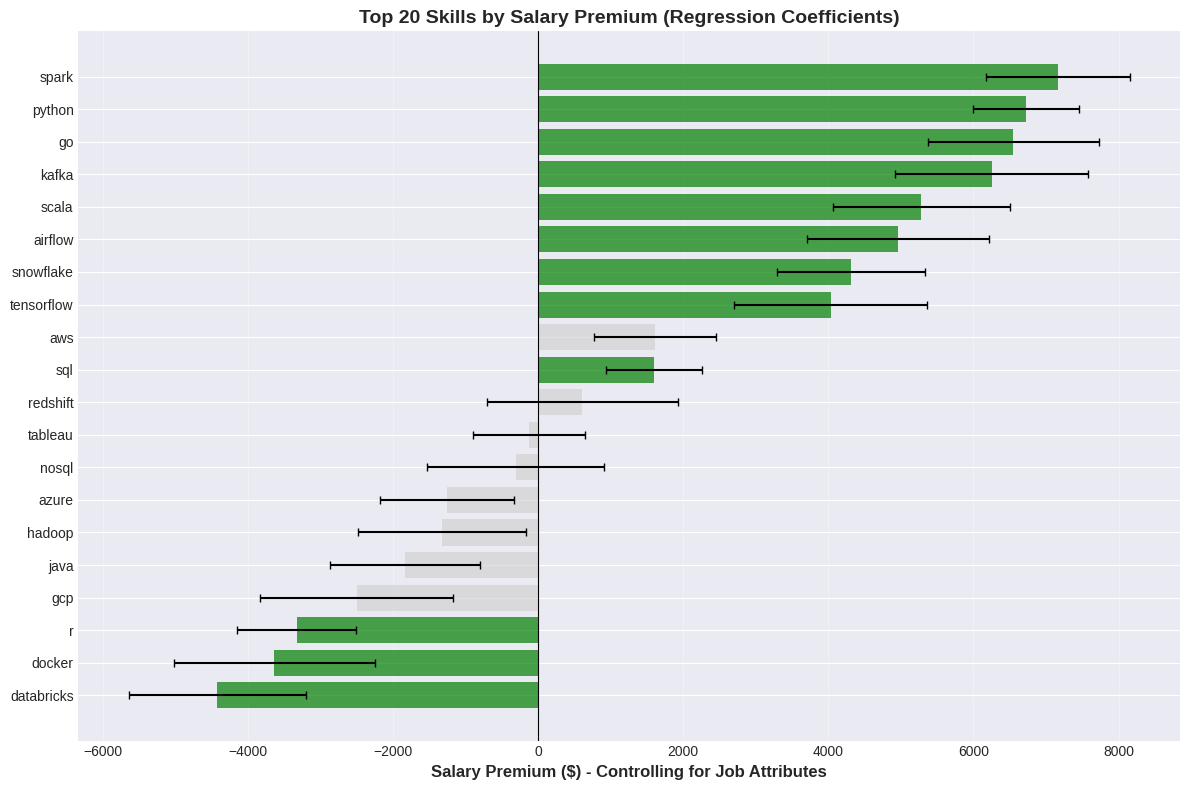


Regression analysis saved to 'skills_regression_analysis.csv'


In [ ]:
# Linear regression to estimate skill premiums while controlling for attributes
print("REGRESSION ANALYSIS: SKILL PREMIUMS CONTROLLING FOR JOB ATTRIBUTES")
# Prepare data for regression
df_reg = df_2023.copy()

# Create dummy variables for categorical attributes
dummies_list = []
control_vars = []

for attr in categorical_cols:
    if attr in df_reg.columns:
        # Ensure dummy variables are integers (0 or 1)
        dummies = pd.get_dummies(df_reg[attr], prefix=attr, drop_first=True, dtype=int)
        dummies_list.append(dummies)
        control_vars.extend(dummies.columns.tolist())

# Combine all features
if len(dummies_list) > 0:
    X_controls = pd.concat(dummies_list, axis=1)
else:
    X_controls = pd.DataFrame()

# Add skill indicators
skill_cols = [col for col in df_reg.columns if col.startswith('skill_')]
if len(skill_cols) > 0:
    X_skills = df_reg[skill_cols]
    if len(X_controls) > 0:
        X = pd.concat([X_controls, X_skills], axis=1)
    else:
        X = X_skills

    # Add constant
    X = sm.add_constant(X, has_constant='add') # Use has_constant='add' for robustness
    y = df_reg['salary']

    # Fit OLS model
    print("\nFitting OLS regression model...")
    print(f"  Features: {len(X.columns)} ({len(control_vars)} controls + {len(skill_cols)} skills)")
    print(f"  Observations: {len(y):,}")

    model = sm.OLS(y, X).fit()

    # Extract skill coefficients
    skill_coeffs = []
    for skill in common_skills:
        col_name = f'skill_{skill}'
        if col_name in model.params.index:
            coeff = model.params[col_name]
            p_val = model.pvalues[col_name]
            std_err = model.bse[col_name]
            conf_int = model.conf_int().loc[col_name]

            skill_coeffs.append({
                'Skill': skill,
                'Coefficient': coeff,
                'Std_Error': std_err,
                'P-value': p_val,
                'Significant': p_val < 0.05,
                'CI_Lower': conf_int[0],
                'CI_Upper': conf_int[1]
            })

    # Create DataFrame
    skill_reg_df = pd.DataFrame(skill_coeffs).sort_values('Coefficient', ascending=False)

    print("MODEL SUMMARY")
    print(f"  R-squared: {model.rsquared:.4f}")
    print(f"  Adjusted R-squared: {model.rsquared_adj:.4f}")
    print(f"  F-statistic: {model.fvalue:.2f}")
    print(f"  Prob (F-statistic): {model.f_pvalue:.4e}")

    print("TOP 15 SKILLS BY SALARY PREMIUM (CONTROLLING FOR ATTRIBUTES)")
    top_15_reg = skill_reg_df.head(15).copy()
    top_15_reg['Coefficient'] = top_15_reg['Coefficient'].apply(lambda x: f'${x:,.0f}')
    top_15_reg['P-value'] = top_15_reg['P-value'].apply(lambda x: f'{x:.4f}')
    print(top_15_reg[['Skill', 'Coefficient', 'P-value', 'Significant']].to_string(index=False))

    # Visualize regression coefficients
    fig, ax = plt.subplots(figsize=(12, 8))
    top_20_reg = skill_reg_df.head(20)
    colors_reg = ['green' if sig else 'lightgray' for sig in top_20_reg['Significant']]
    y_pos = range(len(top_20_reg))

    ax.barh(y_pos, top_20_reg['Coefficient'], xerr=top_20_reg['Std_Error'],
            color=colors_reg, alpha=0.7, capsize=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_20_reg['Skill'])
    ax.set_xlabel('Salary Premium ($) - Controlling for Job Attributes', fontsize=12, fontweight='bold')
    ax.set_title('Top 20 Skills by Salary Premium (Regression Coefficients)', fontsize=14, fontweight='bold')
    ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

    # Save results
    skill_reg_df.to_csv('skills_regression_analysis.csv', index=False)
    print("\nRegression analysis saved to 'skills_regression_analysis.csv'")

else:
    print("No skills data available for regression analysis")

SKILL BUNDLES ANALYSIS

Top 10 Skill Combinations by Salary Premium:
  Skill_1 Skill_2  Frequency Avg_Salary Premium
   python   spark       3298   $143,712 $35,107
      aws  python       3977   $138,340 $30,037
     java  python       2426   $137,984 $27,993
      aws   spark       1879   $143,324 $26,783
    spark     sql       2761   $143,463 $25,167
    azure  python       2553   $133,365 $24,217
   python     sql       9072   $132,071 $19,976
   python       r       4700   $128,893 $18,280
      aws     sql       3316   $134,869 $17,979
snowflake     sql       1990   $136,691 $16,883


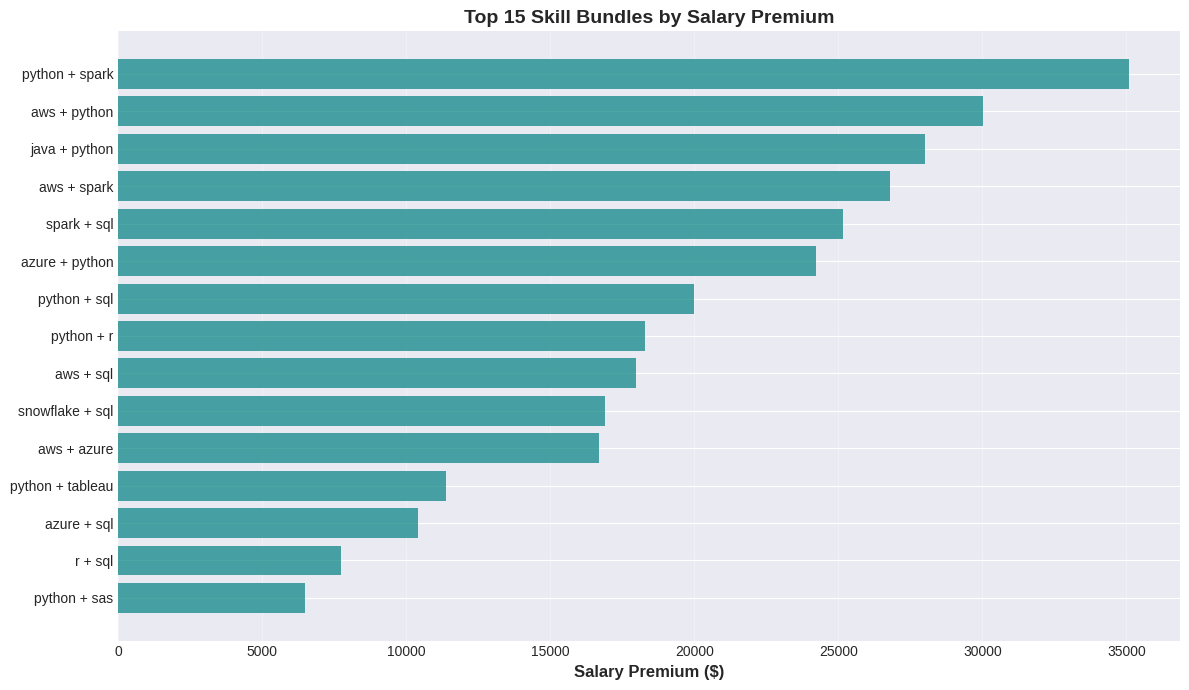


Skill bundles analysis saved to 'skill_bundles_analysis.csv'


In [ ]:
# Analyze common skill bundles/combinations
print("SKILL BUNDLES ANALYSIS")
if len(common_skills) > 0:
    from itertools import combinations

    # Find most common 2-skill combinations
    skill_pairs = []
    for skills_list in df_2023['skills_list']:
        if len(skills_list) >= 2:
            # Get skills that are in common_skills
            filtered_skills = [s for s in skills_list if s in common_skills]
            if len(filtered_skills) >= 2:
                for pair in combinations(sorted(filtered_skills), 2):
                    skill_pairs.append(pair)

    # Count frequencies
    from collections import Counter
    pair_counts = Counter(skill_pairs)

    # Analyze top combinations
    top_pairs = pair_counts.most_common(20)

    if len(top_pairs) > 0:
        pair_analysis = []

        for (skill1, skill2), count in top_pairs:
            # Find jobs with this combination
            has_both = df_2023['skills_list'].apply(lambda x: skill1 in x and skill2 in x)
            has_none = df_2023['skills_list'].apply(lambda x: skill1 not in x and skill2 not in x)

            salary_with_both = df_2023[has_both]['salary'].mean()
            salary_without = df_2023[has_none]['salary'].mean()
            premium = salary_with_both - salary_without

            pair_analysis.append({
                'Skill_1': skill1,
                'Skill_2': skill2,
                'Frequency': count,
                'Avg_Salary': salary_with_both,
                'Premium': premium
            })

        pairs_df = pd.DataFrame(pair_analysis).sort_values('Premium', ascending=False)

        print(f"\nTop 10 Skill Combinations by Salary Premium:")
        top_10_pairs = pairs_df.head(10).copy()
        top_10_pairs['Avg_Salary'] = top_10_pairs['Avg_Salary'].apply(lambda x: f'${x:,.0f}')
        top_10_pairs['Premium'] = top_10_pairs['Premium'].apply(lambda x: f'${x:,.0f}')
        print(top_10_pairs.to_string(index=False))

        # Visualize
        fig, ax = plt.subplots(figsize=(12, 7))
        bundle_labels = [f"{row['Skill_1']} + {row['Skill_2']}" for _, row in pairs_df.head(15).iterrows()]
        ax.barh(range(len(bundle_labels)), pairs_df.head(15)['Premium'], alpha=0.7, color='teal')
        ax.set_yticks(range(len(bundle_labels)))
        ax.set_yticklabels(bundle_labels)
        ax.set_xlabel('Salary Premium ($)', fontsize=12, fontweight='bold')
        ax.set_title('Top 15 Skill Bundles by Salary Premium', fontsize=14, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        ax.invert_yaxis()

        plt.tight_layout()
        plt.show()

        pairs_df.to_csv('skill_bundles_analysis.csv', index=False)
        print("\nSkill bundles analysis saved to 'skill_bundles_analysis.csv'")
    else:
        print("Not enough skill combinations found")
else:
    print("No skills data available for bundle analysis")

---
## 🤖 Machine Learning: Salary Prediction

In this section we build a robust regression pipeline to predict job salaries.
Key design decisions:

1. **Log-transformed target** (`np.log1p(salary)`) to reduce skew and heteroscedasticity.
2. **OneHotEncoder** for nominal categorical features (no ordinal assumptions).
3. **scikit-learn Pipeline + ColumnTransformer** for leak-free preprocessing.
4. Six models compared: Linear, Ridge, Lasso, Random Forest, XGBoost, LightGBM.
5. Hyperparameter tuning via RandomizedSearchCV with 5-fold CV.
6. All metrics (RMSE, MAE) reported back on the **original salary scale**.


In [ ]:
# ─────────────────────────────────────────────────────────────
# Feature Engineering
# ─────────────────────────────────────────────────────────────
print("FEATURE ENGINEERING")

df_ml = df_2023.copy().reset_index(drop=True)

# --- 1. Job role (from job_title_short) ---
df_ml['job_role'] = df_ml['job_title_short'].fillna('Unknown').astype(str)

# Seniority flag (engineer feature)
df_ml['is_senior'] = df_ml['job_role'].str.lower().str.contains('senior').astype(int)

# --- 2. Country ---
df_ml['country'] = df_ml['job_country'].fillna('Unknown').astype(str)
country_counts = df_ml['country'].value_counts()
top_countries = country_counts[country_counts >= 50].index.tolist()
df_ml['country'] = df_ml['country'].apply(lambda x: x if x in top_countries else 'Other')

# --- 3. Remote status ---
df_ml['is_remote'] = df_ml['job_work_from_home'].fillna(False).astype(int)

# --- 4. Schedule type ---
df_ml['schedule_type'] = df_ml['job_schedule_type'].fillna('Unknown').astype(str)
# Group rare schedule types
sched_counts = df_ml['schedule_type'].value_counts()
common_sched = sched_counts[sched_counts >= 100].index.tolist()
df_ml['schedule_type'] = df_ml['schedule_type'].apply(lambda x: x if x in common_sched else 'Other')

# --- 5. Job location – extract US state if possible ---
df_ml['job_location'] = df_ml['job_location'].fillna('').astype(str)
import re
def extract_state(loc):
    """Extract 2-letter US state code from location string."""
    if not loc:
        return 'Unknown'
    m = re.search(r'\b([A-Z]{2})\b$', loc.strip())
    if m:
        return m.group(1)
    return 'Non-US'
df_ml['job_state'] = df_ml['job_location'].apply(extract_state)
# Group rare states
state_counts = df_ml['job_state'].value_counts()
common_states = state_counts[state_counts >= 100].index.tolist()
df_ml['job_state'] = df_ml['job_state'].apply(lambda x: x if x in common_states else 'Other')

# --- 6. Job posting source (job_via) – simplify ---
df_ml['job_via'] = df_ml['job_via'].fillna('Unknown').astype(str)
# Extract platform name (after "via ")
df_ml['posting_platform'] = df_ml['job_via'].apply(
    lambda x: x.replace('via ', '').strip().split(',')[0].strip() if x else 'Unknown'
)
# Group rare platforms
plat_counts = df_ml['posting_platform'].value_counts()
common_plat = plat_counts[plat_counts >= 100].index.tolist()
df_ml['posting_platform'] = df_ml['posting_platform'].apply(lambda x: x if x in common_plat else 'Other')

# --- 7. Search location ---
df_ml['search_location'] = df_ml['search_location'].fillna('Unknown').astype(str)
sl_counts = df_ml['search_location'].value_counts()
common_sl = sl_counts[sl_counts >= 100].index.tolist()
df_ml['search_location'] = df_ml['search_location'].apply(lambda x: x if x in common_sl else 'Other')

# --- 8. Binary flags ---
df_ml['no_degree_mention'] = df_ml['job_no_degree_mention'].fillna(False).astype(int)
df_ml['has_health_insurance'] = df_ml['job_health_insurance'].fillna(False).astype(int)

# --- 9. Salary rate indicator ---
df_ml['salary_rate'] = df_ml['salary_rate'].fillna('YEARLY').astype(str)

# --- 10. Job posting date features ---
if 'job_posted_date' in df_ml.columns:
    df_ml['job_posted_date'] = pd.to_datetime(df_ml['job_posted_date'], errors='coerce')
    df_ml['posting_month'] = df_ml['job_posted_date'].dt.month.fillna(0).astype(int)
    df_ml['posting_quarter'] = df_ml['job_posted_date'].dt.quarter.fillna(0).astype(int)

# --- 11. Skills ---
# Use skills_list already created in Cell 6; recreate if missing
if 'skills_list' not in df_ml.columns:
    skills_by_job = []
    for skills in df_ml['job_skills']:
        if pd.notna(skills):
            if isinstance(skills, str):
                sl = eval(skills) if skills.startswith('[') else [s.strip() for s in skills.split(',')]
            elif isinstance(skills, list):
                sl = skills
            else:
                sl = []
            skills_by_job.append([s.lower().strip() for s in sl if s])
        else:
            skills_by_job.append([])
    df_ml['skills_list'] = skills_by_job

# Count total skills
df_ml['num_skills'] = df_ml['skills_list'].apply(len)
df_ml['has_skills'] = (df_ml['num_skills'] > 0).astype(int)

# Skill categories from job_type_skills
if 'job_type_skills' in df_ml.columns:
    def count_skill_types(x):
        if pd.notna(x) and isinstance(x, dict):
            return len(x)
        return 0
    df_ml['num_skill_categories'] = df_ml['job_type_skills'].apply(count_skill_types)

# Top skills (same as before, but ensure consistency)
skill_counts = {}
for skills in df_ml['skills_list']:
    for s in skills:
        skill_counts[s] = skill_counts.get(s, 0) + 1
min_count = len(df_ml) * 0.03  # Lowered to 3% to capture more skills
top_skills = sorted([s for s, c in skill_counts.items() if c >= min_count],
                    key=lambda x: skill_counts[x], reverse=True)[:40]
for skill in top_skills:
    safe_name = skill.replace(' ', '_').replace('+', 'plus').replace('#', 'sharp')
    df_ml[f'skill_{safe_name}'] = df_ml['skills_list'].apply(lambda lst: 1 if skill in lst else 0)

# Skill-group aggregates
cloud_skills = ['aws', 'azure', 'gcp', 'google_cloud']
ml_skills    = ['tensorflow', 'pytorch', 'keras', 'scikit', 'sklearn']
df_ml['n_cloud_skills'] = df_ml['skills_list'].apply(lambda l: sum(1 for s in l if s in cloud_skills))
df_ml['n_ml_skills']    = df_ml['skills_list'].apply(lambda l: sum(1 for s in l if s in ml_skills))

print(f"  Dataset shape after feature engineering: {df_ml.shape}")
print(f"  Engineered skill indicator columns: {len(top_skills)}")
print(f"  Top skills: {top_skills[:10]}")
print(f"  Categorical features: job_role, country, schedule_type, job_state, posting_platform, search_location, salary_rate")
print(f"  Numeric features: is_remote, is_senior, no_degree_mention, has_health_insurance, num_skills, "
      f"has_skills, n_cloud_skills, n_ml_skills, posting_month, posting_quarter, num_skill_categories")

FEATURE ENGINEERING
  Dataset shape after feature engineering: (22003, 79)
  Engineered skill indicator columns: 40
  Top skills: ['sql', 'python', 'r', 'aws', 'tableau', 'spark', 'excel', 'azure', 'sas', 'java']
  Categorical features: job_role, country, schedule_type, job_state, posting_platform, search_location, salary_rate
  Numeric features: is_remote, is_senior, no_degree_mention, has_health_insurance, num_skills, has_skills, n_cloud_skills, n_ml_skills, posting_month, posting_quarter, num_skill_categories


In [ ]:
# ─────────────────────────────────────────────────────────────
# Define Features, Target & Train/Test Split
# ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

# Categorical columns (nominal → OneHotEncoder)
cat_features = [
    'job_role', 'country', 'schedule_type',
    'job_state', 'posting_platform', 'search_location', 'salary_rate'
]

# Numeric columns (no encoding needed, just scaling)
num_features = [
    'is_remote', 'is_senior', 'no_degree_mention', 'has_health_insurance',
    'num_skills', 'has_skills', 'n_cloud_skills', 'n_ml_skills',
    'posting_month', 'posting_quarter', 'num_skill_categories'
]

# Skill indicator columns (already 0/1, no scaling needed)
skill_cols = [c for c in df_ml.columns if c.startswith('skill_')]

# Validate all columns exist
cat_features  = [c for c in cat_features if c in df_ml.columns]
num_features  = [c for c in num_features if c in df_ml.columns]

all_feature_names = cat_features + num_features + skill_cols
X = df_ml[all_feature_names].copy()
y = df_ml['salary'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"  Categorical features (OneHot): {len(cat_features)}")
print(f"  Numeric features:             {len(num_features)}")
print(f"  Skill indicator features:     {len(skill_cols)}")
print(f"  Total raw features:           {len(all_feature_names)}")

# ── Log-transform the target ──
y_log = np.log1p(y)
print(f"\nTarget (salary) – original skew: {y.skew():.3f}")
print(f"Target (log salary) – skew:      {y_log.skew():.3f}")

# ── Train / test split ──
# Perform train/test split on both original target 'y' and log-transformed target 'y_log'
# to ensure both sets are split consistently with respect to X.
X_train, X_test, y_train, y_test, y_train_log, y_test_log = train_test_split(
    X, y, y_log, test_size=0.2, random_state=42
)

print(f"\nTrain: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")

Feature matrix shape: (22003, 60)
  Categorical features (OneHot): 7
  Numeric features:             11
  Skill indicator features:     42
  Total raw features:           60

Target (salary) – original skew: 1.747
Target (log salary) – skew:      -0.180

Train: 17,602 rows  |  Test: 4,401 rows


In [ ]:
# ─────────────────────────────────────────────────────────────
# Build Preprocessing Pipeline (ColumnTransformer)
# ─────────────────────────────────────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# OneHotEncoder for nominal categoricals
# handle_unknown='ignore' prevents errors on unseen categories in test set
categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False,
    drop='first'          # Avoid dummy variable trap
)

# StandardScaler for numeric features
numeric_transformer = StandardScaler()

# ColumnTransformer routes columns to the right preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, cat_features),
        ('num', numeric_transformer,     num_features),
        # skill_cols are already 0/1 binary → pass through unchanged
        ('skill', 'passthrough',         skill_cols)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

print("Preprocessor configured:")
print(f"  Categorical → OneHotEncoder (drop='first')")
print(f"  Numeric     → StandardScaler")
print(f"  Skills      → passthrough (binary)")
print(f"  Remainder   → drop")

# Quick fit to see output dimension
preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
print(f"\nTransformed feature matrix shape: {X_train_transformed.shape}")
print(f"  (Features expanded from {len(all_feature_names)} via OneHotEncoding)")

Preprocessor configured:
  Categorical → OneHotEncoder (drop='first')
  Numeric     → StandardScaler
  Skills      → passthrough (binary)
  Remainder   → drop

Transformed feature matrix shape: (17602, 153)
  (Features expanded from 60 via OneHotEncoding)


In [ ]:
# ─────────────────────────────────────────────────────────────
# Train All 6 Models (Baseline) on Log-Transformed Salary
# ─────────────────────────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score

# Helper: evaluate in original scale
def evaluate_model(y_test_original, y_pred_log):
    """Convert log predictions back and compute metrics on original scale."""
    y_pred_original = np.expm1(y_pred_log)
    # Clip negatives (can happen with log transform)
    y_pred_original = np.maximum(y_pred_original, 0)
    r2   = r2_score(y_test_original, y_pred_original)
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    mae  = mean_absolute_error(y_test_original, y_pred_original)
    return r2, rmse, mae, y_pred_original

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=1.0, max_iter=5000),
    'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1),
    'XGBoost':           XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                                      random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM':          LGBMRegressor(n_estimators=200, max_depth=10, learning_rate=0.1,
                                       random_state=42, n_jobs=-1, verbose=-1),
}

baseline_results = []
trained_pipelines = {}

print("BASELINE MODEL TRAINING (5-Fold CV, log-transformed target)")
print("=" * 75)

for name, estimator in models.items():
    print(f"\n  Training: {name}...", end=' ', flush=True)

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator)
    ])

    # 5-fold CV on training set (scoring on R² in log-space)
    cv_scores = cross_val_score(pipe, X_train, y_train_log, cv=5, scoring='r2', n_jobs=-1)
    cv_mean = cv_scores.mean()
    cv_std  = cv_scores.std()

    # Fit on full training set
    pipe.fit(X_train, y_train_log)

    # Predict on test set (in log-space), then convert back
    y_pred_log_test = pipe.predict(X_test)
    test_r2, test_rmse, test_mae, y_pred_original = evaluate_model(y_test, y_pred_log_test)

    trained_pipelines[name] = pipe

    baseline_results.append({
        'Model':     name,
        'CV_R2_Mean': cv_mean,
        'CV_R2_Std':  cv_std,
        'Test_R2':   test_r2,
        'Test_RMSE': test_rmse,
        'Test_MAE':  test_mae
    })

    print(f"CV R²={cv_mean:.4f}±{cv_std:.4f}  |  Test R²={test_r2:.4f}  |  RMSE=${test_rmse:,.0f}  |  MAE=${test_mae:,.0f}")

baseline_df = pd.DataFrame(baseline_results).sort_values('Test_R2', ascending=False)
print("\n" + "=" * 75)
print("BASELINE MODEL COMPARISON (sorted by Test R²)")
print(baseline_df.to_string(index=False))

BASELINE MODEL TRAINING (5-Fold CV, log-transformed target)

  Training: Linear Regression... CV R²=0.3384±0.0170  |  Test R²=0.2860  |  RMSE=$41,348  |  MAE=$28,619

  Training: Ridge... CV R²=0.3385±0.0170  |  Test R²=0.2862  |  RMSE=$41,343  |  MAE=$28,607

  Training: Lasso... CV R²=-0.0001±0.0001  |  Test R²=-0.0323  |  RMSE=$49,717  |  MAE=$35,853

  Training: Random Forest... CV R²=0.3943±0.0204  |  Test R²=0.3584  |  RMSE=$39,194  |  MAE=$26,274

  Training: XGBoost... CV R²=0.3935±0.0153  |  Test R²=0.3525  |  RMSE=$39,376  |  MAE=$26,528

  Training: LightGBM... CV R²=0.3975±0.0156  |  Test R²=0.3550  |  RMSE=$39,299  |  MAE=$26,379

BASELINE MODEL COMPARISON (sorted by Test R²)
            Model  CV_R2_Mean  CV_R2_Std   Test_R2    Test_RMSE     Test_MAE
    Random Forest    0.394305   0.020352  0.358445 39194.459145 26274.331498
         LightGBM    0.397498   0.015621  0.355005 39299.407559 26378.781792
          XGBoost    0.393502   0.015250  0.352494 39375.822666 26527.6

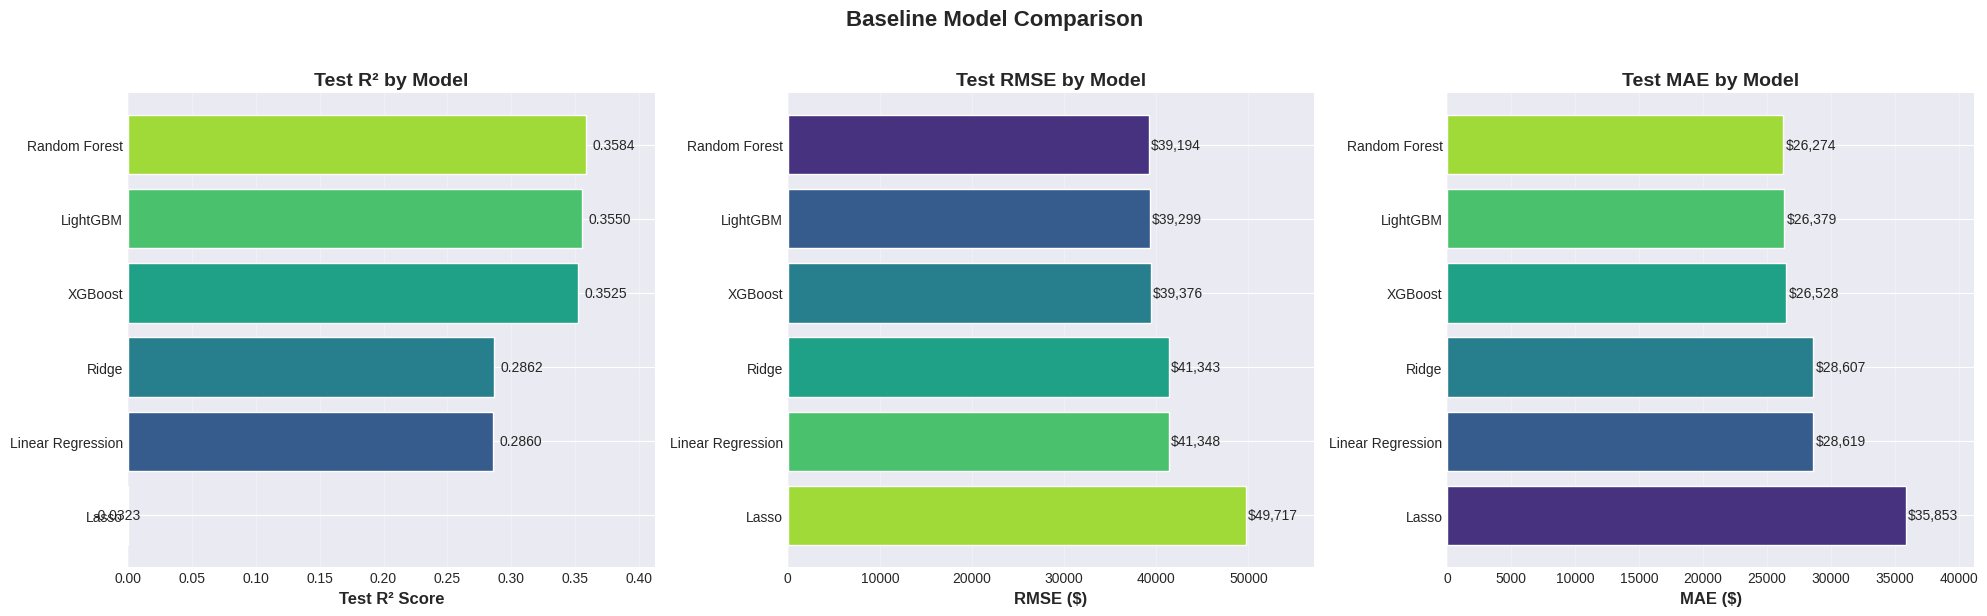

In [ ]:
# ─────────────────────────────────────────────────────────────
# Model Comparison Visualization
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

df_plot = baseline_df.sort_values('Test_R2', ascending=True)
colors = sns.color_palette("viridis", n_colors=len(df_plot))

# 1. Test R²
axes[0].barh(df_plot['Model'], df_plot['Test_R2'], color=colors, edgecolor='white')
axes[0].set_xlabel('Test R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Test R² by Model', fontsize=14, fontweight='bold')
for i, (v, model) in enumerate(zip(df_plot['Test_R2'], df_plot['Model'])):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)
axes[0].set_xlim(0, max(df_plot['Test_R2']) * 1.15)

# 2. Test RMSE
df_plot_rmse = baseline_df.sort_values('Test_RMSE', ascending=False)
axes[1].barh(df_plot_rmse['Model'], df_plot_rmse['Test_RMSE'], color=colors[::-1], edgecolor='white')
axes[1].set_xlabel('RMSE ($)', fontsize=12, fontweight='bold')
axes[1].set_title('Test RMSE by Model', fontsize=14, fontweight='bold')
for i, (v, model) in enumerate(zip(df_plot_rmse['Test_RMSE'], df_plot_rmse['Model'])):
    axes[1].text(v + 200, i, f'${v:,.0f}', va='center', fontsize=10)
axes[1].set_xlim(0, max(df_plot_rmse['Test_RMSE']) * 1.15)

# 3. Test MAE
df_plot_mae = baseline_df.sort_values('Test_MAE', ascending=False)
axes[2].barh(df_plot_mae['Model'], df_plot_mae['Test_MAE'], color=colors, edgecolor='white')
axes[2].set_xlabel('MAE ($)', fontsize=12, fontweight='bold')
axes[2].set_title('Test MAE by Model', fontsize=14, fontweight='bold')
for i, (v, model) in enumerate(zip(df_plot_mae['Test_MAE'], df_plot_mae['Model'])):
    axes[2].text(v + 200, i, f'${v:,.0f}', va='center', fontsize=10)
axes[2].set_xlim(0, max(df_plot_mae['Test_MAE']) * 1.15)

for ax in axes:
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Baseline Model Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import os
import time
import numpy as np
import pandas as pd
from joblib import Memory
from scipy.stats import randint, uniform, loguniform
from tqdm.auto import tqdm

from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

# SETTINGS YOU CAN ADJUST
FAST_MODE = True                 # True = fewer iterations, quicker result
CV_FOLDS = 3                    # 3 is much faster than 5
RF_N_ITER = 20 if FAST_MODE else 35
XGB_N_ITER = 25 if FAST_MODE else 40
LGB_N_ITER = 25 if FAST_MODE else 40
RANDOM_STATE = 42
CACHE_DIR = './sk_cache'
os.makedirs(CACHE_DIR, exist_ok=True)
mem = Memory(location=CACHE_DIR, verbose=0)

# SELECT TOP 3 MODELS
top3_names = baseline_df.head(3)['Model'].tolist()
print(f"Tuning top 3 models: {top3_names}")
print("=" * 80)

# BUILD SEARCH OBJECTS
search_objects = {}

if 'Random Forest' in top3_names:
    rf_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
    ], memory=mem)

    rf_params = {
        'model__n_estimators': randint(120, 320),
        'model__max_depth': [10, 15, 20, None],
        'model__min_samples_split': randint(2, 12),
        'model__min_samples_leaf': randint(1, 6),
        'model__max_features': ['sqrt', 'log2', 0.5, 0.7]
    }

    search_objects['Random Forest'] = RandomizedSearchCV(
        estimator=rf_pipe,
        param_distributions=rf_params,
        n_iter=RF_N_ITER,
        cv=CV_FOLDS,
        scoring='r2',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
        refit=True
    )

if 'XGBoost' in top3_names:
    xgb_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
            tree_method='hist',
            eval_metric='rmse'
        ))
    ], memory=mem)

    xgb_params = {
        'model__n_estimators': randint(120, 350),
        'model__max_depth': randint(3, 9),
        'model__learning_rate': loguniform(0.01, 0.2),
        'model__subsample': uniform(0.7, 0.3),
        'model__colsample_bytree': uniform(0.6, 0.4),
        'model__reg_alpha': loguniform(1e-3, 3),
        'model__reg_lambda': loguniform(1e-3, 3),
        'model__min_child_weight': randint(1, 8)
    }

    search_objects['XGBoost'] = RandomizedSearchCV(
        estimator=xgb_pipe,
        param_distributions=xgb_params,
        n_iter=XGB_N_ITER,
        cv=CV_FOLDS,
        scoring='r2',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
        refit=True
    )

if 'LightGBM' in top3_names:
    lgb_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', LGBMRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
            force_col_wise=True
        ))
    ], memory=mem)

    lgb_params = {
        'model__n_estimators': randint(120, 350),
        'model__max_depth': randint(3, 10),
        'model__learning_rate': loguniform(0.01, 0.2),
        'model__num_leaves': randint(20, 70),
        'model__subsample': uniform(0.7, 0.3),
        'model__colsample_bytree': uniform(0.6, 0.4),
        'model__reg_alpha': loguniform(1e-3, 3),
        'model__reg_lambda': loguniform(1e-3, 3),
        'model__min_child_samples': randint(10, 40)
    }

    search_objects['LightGBM'] = RandomizedSearchCV(
        estimator=lgb_pipe,
        param_distributions=lgb_params,
        n_iter=LGB_N_ITER,
        cv=CV_FOLDS,
        scoring='r2',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
        refit=True
    )

# Ridge is cheap, so grid search is fine
ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(max_iter=5000))
], memory=mem)

ridge_params = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 500.0]
}

search_objects['Ridge'] = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_params,
    cv=CV_FOLDS,
    scoring='r2',
    n_jobs=-1,
    refit=True
)

# ESTIMATE TOTAL RUNTIME USING A SMALL PILOT FIT
def estimate_runtime(search_obj, X_train, y_train_log, label='Model', sample_frac=0.25, random_state=42):
    """
    Estimate runtime by fitting ONE randomly sampled parameter setting on a subset.
    This gives a rough estimate only.
    """
    n_sample = max(500, int(len(X_train) * sample_frac)) if hasattr(X_train, '__len__') else None

    if isinstance(X_train, pd.DataFrame):
        X_sample = X_train.sample(n=min(n_sample, len(X_train)), random_state=random_state)
        y_sample = y_train_log.loc[X_sample.index] if hasattr(y_train_log, 'loc') else y_train_log[X_sample.index]
    else:
        idx = np.random.RandomState(random_state).choice(len(X_train), size=min(n_sample, len(X_train)), replace=False)
        X_sample = X_train[idx]
        y_sample = y_train_log[idx]

    start = time.perf_counter()

    # One quick pilot search: 1 parameter draw only
    if hasattr(search_obj, 'param_distributions'):
        pilot = RandomizedSearchCV(
            estimator=search_obj.estimator,
            param_distributions=search_obj.param_distributions,
            n_iter=1,
            cv=search_obj.cv,
            scoring=search_obj.scoring,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=0,
            refit=False
        )
        pilot.fit(X_sample, y_sample)
        elapsed = time.perf_counter() - start
        estimated_total = elapsed * search_obj.n_iter
    else:
        # GridSearchCV case
        pilot = GridSearchCV(
            estimator=search_obj.estimator,
            param_grid={'model__alpha': [ridge_params['model__alpha'][0]]},
            cv=search_obj.cv,
            scoring=search_obj.scoring,
            n_jobs=-1,
            refit=False
        )
        pilot.fit(X_sample, y_sample)
        elapsed = time.perf_counter() - start
        estimated_total = elapsed * len(ridge_params['model__alpha'])

    # Scale estimate from sample size to full size very roughly.
    # Tree models are not perfectly linear, but this is good enough as a rough guide.
    sample_ratio = len(X_train) / len(X_sample)
    adjusted_total = estimated_total * sample_ratio

    return {
        'pilot_seconds': elapsed,
        'estimated_total_seconds': adjusted_total
    }

print("Estimating runtime before full tuning...\n")
time_estimates = {}
for name, search_obj in search_objects.items():
    est = estimate_runtime(search_obj, X_train, y_train_log, label=name, sample_frac=0.25, random_state=RANDOM_STATE)
    time_estimates[name] = est
    print(f"{name:<15} | pilot: {est['pilot_seconds']:.1f}s | estimated full run: {est['estimated_total_seconds']/60:.1f} min")

total_est_minutes = sum(v['estimated_total_seconds'] for v in time_estimates.values()) / 60
print(f"Estimated total tuning time: ~{total_est_minutes:.1f} minutes")
print("Note: This is a rough estimate. Actual time depends on dataset size, number of features after preprocessing, and CPU cores.")

# RUN FULL TUNING
tuned_results = {}
pbar = tqdm(total=len(search_objects), desc='Overall Tuning Progress')

for model_name, search_obj in search_objects.items():
    print(f"\nTuning {model_name}...")
    start_time = time.perf_counter()

    search_obj.fit(X_train, y_train_log)

    elapsed = time.perf_counter() - start_time

    if isinstance(search_obj, RandomizedSearchCV):
        best_params = {k.replace('model__', ''): v for k, v in search_obj.best_params_.items()}
    else:
        best_params = {'alpha': search_obj.best_params_['model__alpha']}

    tuned_results[model_name] = {
        'best_cv_r2': search_obj.best_score_,
        'best_params': best_params,
        'pipeline': search_obj.best_estimator_,
        'fit_time_min': elapsed / 60
    }

    print(f"  Best CV R² : {search_obj.best_score_:.4f}")
    print(f"  Time taken : {elapsed / 60:.2f} min")
    print(f"  Best params: {best_params}")
    pbar.update(1)

pbar.close()

# RESULTS SUMMARY
tuned_df = pd.DataFrame([
    {
        'Model': model_name,
        'Best CV R²': info['best_cv_r2'],
        'Fit Time (min)': info['fit_time_min'],
        'Best Params': info['best_params']
    }
    for model_name, info in tuned_results.items()
]).sort_values(by='Best CV R²', ascending=False).reset_index(drop=True)

print("\nTuned model summary:")
display(tuned_df)

Tuning top 3 models: ['Random Forest', 'LightGBM', 'XGBoost']
Estimating runtime before full tuning...

Random Forest   | pilot: 13.3s | estimated full run: 17.8 min
XGBoost         | pilot: 0.8s | estimated full run: 1.3 min
LightGBM        | pilot: 1.4s | estimated full run: 2.3 min
Ridge           | pilot: 0.3s | estimated full run: 0.1 min
Estimated total tuning time: ~21.6 minutes
Note: This is a rough estimate. Actual time depends on dataset size, number of features after preprocessing, and CPU cores.


Overall Tuning Progress:   0%|          | 0/4 [00:00<?, ?it/s]


Tuning Random Forest...
  Best CV R² : 0.4041
  Time taken : 8.54 min
  Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 208}

Tuning XGBoost...
  Best CV R² : 0.4024
  Time taken : 1.47 min
  Best params: {'colsample_bytree': np.float64(0.8080272084711243), 'learning_rate': np.float64(0.05143828405076928), 'max_depth': 8, 'min_child_weight': 5, 'n_estimators': 310, 'reg_alpha': np.float64(0.8486454601041912), 'reg_lambda': np.float64(0.03663107437503339), 'subsample': np.float64(0.8185450708005443)}

Tuning LightGBM...
  Best CV R² : 0.3944
  Time taken : 2.59 min
  Best params: {'colsample_bytree': np.float64(0.6390688456025535), 'learning_rate': np.float64(0.07766184280392888), 'max_depth': 9, 'min_child_samples': 37, 'n_estimators': 318, 'num_leaves': 63, 'reg_alpha': np.float64(0.05269751777340593), 'reg_lambda': np.float64(0.0013169614353741135), 'subsample': np.float64(0.9727961206236346)}

Tuning Ridge...
 

,Model,Best CV R²,Fit Time (min),Best Params
0,Random Forest,0.404147,8.543742,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
1,XGBoost,0.402413,1.473636,"{'colsample_bytree': 0.8080272084711243, 'lear..."
2,LightGBM,0.394420,2.586091,"{'colsample_bytree': 0.6390688456025535, 'lear..."
3,Ridge,0.338637,0.084074,{'alpha': 1.0}


In [ ]:
# Final Evaluation: Baseline vs. Tuned Models
final_rows = []

# Add baseline results
for _, row in baseline_df.iterrows():
    final_rows.append({
        'Model':        row['Model'],
        'Stage':        'Baseline',
        'CV_R2':        f"{row['CV_R2_Mean']:.4f}±{row['CV_R2_Std']:.4f}",
        'Test_R2':      row['Test_R2'],
        'Test_RMSE':    row['Test_RMSE'],
        'Test_MAE':     row['Test_MAE']
    })

# Add tuned results
for name, info in tuned_results.items():
    pipe = info['pipeline']
    y_pred_log = pipe.predict(X_test)
    test_r2, test_rmse, test_mae, _ = evaluate_model(y_test, y_pred_log)
    final_rows.append({
        'Model':     name,
        'Stage':     'Tuned',
        'CV_R2':     f"{info['best_cv_r2']:.4f}",
        'Test_R2':   test_r2,
        'Test_RMSE': test_rmse,
        'Test_MAE':  test_mae
    })

final_df = pd.DataFrame(final_rows)
final_df = final_df.sort_values('Test_R2', ascending=False)

print("=" * 95)
print(f"{'Model':<22} {'Stage':<10} {'CV R²':<18} {'Test R²':>10} {'Test RMSE':>12} {'Test MAE':>12}")
print("-" * 95)
for _, row in final_df.iterrows():
    print(f"{row['Model']:<22} {row['Stage']:<10} {row['CV_R2']:<18} "
          f"{row['Test_R2']:>10.4f} ${row['Test_RMSE']:>10,.0f} ${row['Test_MAE']:>10,.0f}")
print("=" * 95)

# Best model
best_name   = final_df.iloc[0]['Model']
best_stage  = final_df.iloc[0]['Stage']
best_r2     = final_df.iloc[0]['Test_R2']
best_rmse   = final_df.iloc[0]['Test_RMSE']
best_mae    = final_df.iloc[0]['Test_MAE']
print(f"\nBest model: {best_name} ({best_stage})")
print(f"   Test R² = {best_r2:.4f}  |  RMSE = ${best_rmse:,.0f}  |  MAE = ${best_mae:,.0f}")

Model                  Stage      CV R²                 Test R²    Test RMSE     Test MAE
-----------------------------------------------------------------------------------------------
Random Forest          Tuned      0.4041                 0.3702 $    38,835 $    25,787
XGBoost                Tuned      0.4024                 0.3684 $    38,889 $    26,148
LightGBM               Tuned      0.3944                 0.3622 $    39,080 $    26,351
Random Forest          Baseline   0.3943±0.0204          0.3584 $    39,194 $    26,274
LightGBM               Baseline   0.3975±0.0156          0.3550 $    39,299 $    26,379
XGBoost                Baseline   0.3935±0.0153          0.3525 $    39,376 $    26,528
Ridge                  Baseline   0.3385±0.0170          0.2862 $    41,343 $    28,607
Ridge                  Tuned      0.3386                 0.2862 $    41,343 $    28,607
Linear Regression      Baseline   0.3384±0.0170          0.2860 $    41,348 $    28,619
Lasso                 

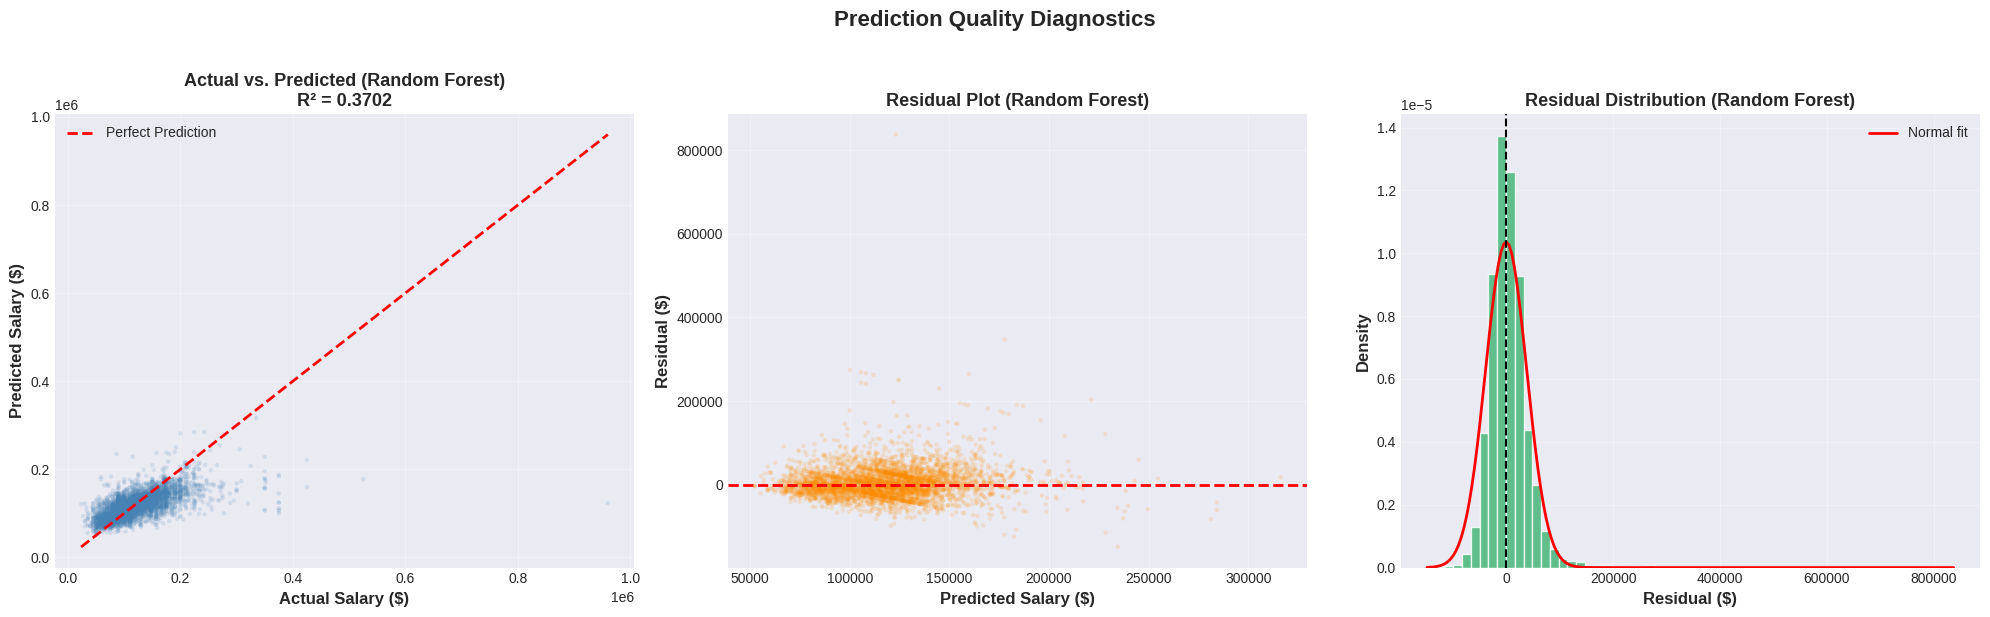

In [ ]:
# Actual vs. Predicted & Residual Plots (Best Model)
best_pipe = tuned_results[best_name]['pipeline'] if best_stage == 'Tuned' else trained_pipelines[best_name]
y_pred_log = best_pipe.predict(X_test)
_, _, _, y_pred = evaluate_model(y_test, y_pred_log)
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.15, s=10, color='steelblue', edgecolors='none')
lim_min = min(y_test.min(), y_pred.min())
lim_max = max(y_test.max(), y_pred.max())
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Salary ($)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Salary ($)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Actual vs. Predicted ({best_name})\nR² = {best_r2:.4f}', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# 2. Residual Plot
axes[1].scatter(y_pred, residuals, alpha=0.15, s=10, color='darkorange', edgecolors='none')
axes[1].axhline(0, color='red', linewidth=2, linestyle='--')
axes[1].set_xlabel('Predicted Salary ($)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Residual ($)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Residual Plot ({best_name})', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

# 3. Residual Distribution
axes[2].hist(residuals, bins=60, color='mediumseagreen', edgecolor='white', alpha=0.8, density=True)
residual_std = residuals.std()
x_range = np.linspace(residuals.min(), residuals.max(), 200)
axes[2].plot(x_range, 1/(residual_std*np.sqrt(2*np.pi)) * np.exp(-0.5*((x_range)/residual_std)**2),
             'r-', linewidth=2, label='Normal fit')
axes[2].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[2].set_xlabel('Residual ($)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Density', fontsize=12, fontweight='bold')
axes[2].set_title(f'Residual Distribution ({best_name})', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)

plt.suptitle('Prediction Quality Diagnostics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Top 25 Features by Importance (Random Forest):
                       Feature  Importance
         job_role_Data Analyst    0.070024
                 posting_month    0.062842
                    num_skills    0.055780
               posting_quarter    0.033826
                  skill_python    0.029341
                   skill_excel    0.025726
       job_role_Data Scientist    0.024249
                  job_state_CA    0.021803
          has_health_insurance    0.019008
                     is_senior    0.018665
                     skill_sql    0.017261
     posting_platform_LinkedIn    0.016677
                n_cloud_skills    0.016385
      posting_platform_Ladders    0.015030
job_role_Senior Data Scientist    0.014810
                   skill_spark    0.013924
        job_role_Data Engineer    0.013088
             no_degree_mention    0.013000
                 skill_tableau    0.012656
                       skill_r    0.011689
       posting_platform_Indeed    0.011640
       

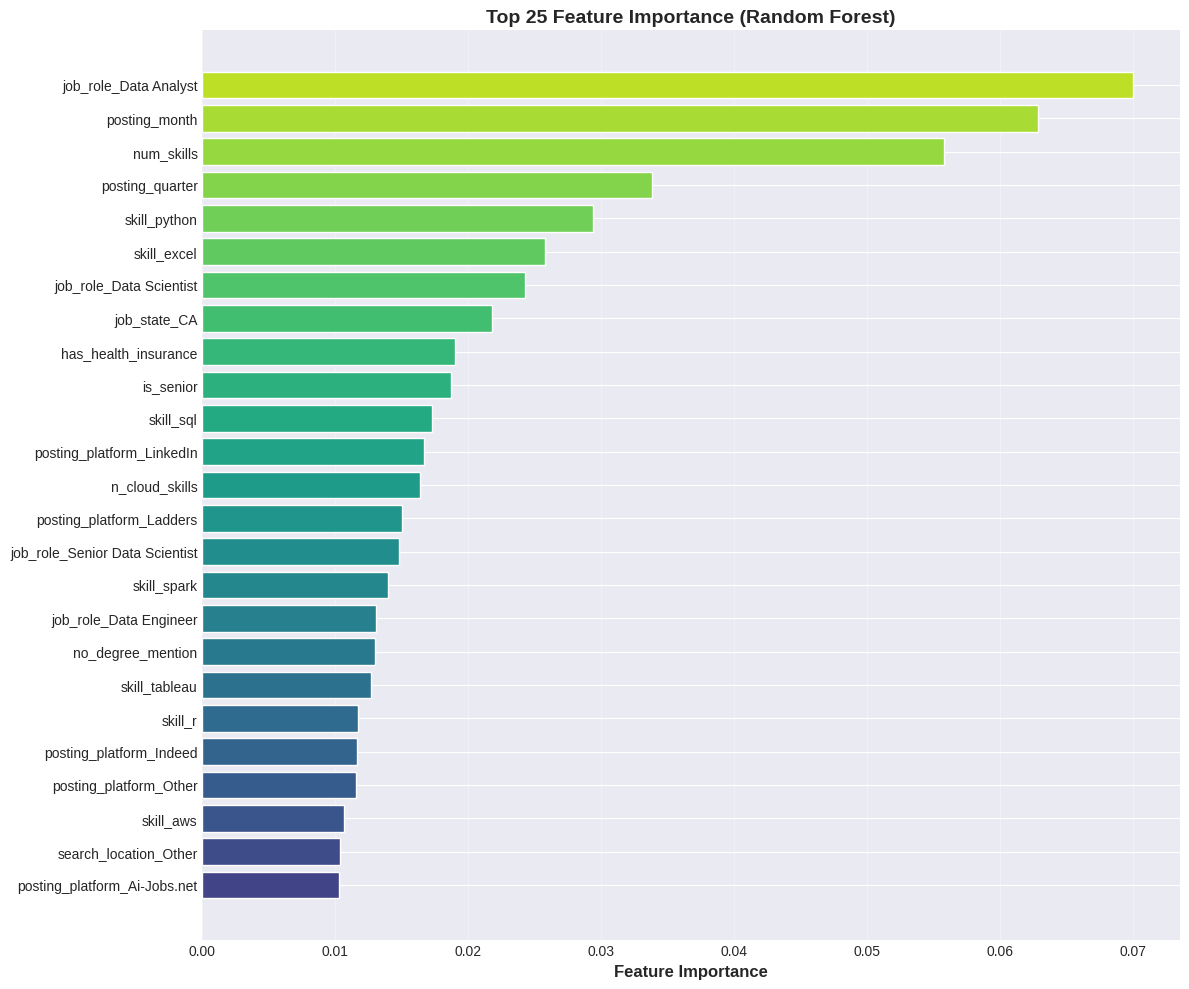

In [ ]:
# Feature Importance (Best Model)
# Get the underlying model from the best pipeline
best_model_obj = best_pipe.named_steps['model']

# Get feature names after preprocessing
feature_names_out = best_pipe.named_steps['preprocessor'].get_feature_names_out()

if hasattr(best_model_obj, 'feature_importances_'):
    importances = best_model_obj.feature_importances_
    fi_df = pd.DataFrame({
        'Feature': feature_names_out,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    print(f"Top 25 Features by Importance ({best_name}):")
    print(fi_df.head(25).to_string(index=False))

    fig, ax = plt.subplots(figsize=(12, 10))
    top25 = fi_df.head(25)
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top25)))
    ax.barh(range(len(top25)), top25['Importance'].values, color=colors[::-1], edgecolor='white')
    ax.set_yticks(range(len(top25)))
    ax.set_yticklabels(top25['Feature'].values, fontsize=10)
    ax.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
    ax.set_title(f'Top 25 Feature Importance ({best_name})', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_name} does not have native feature_importances_. Using SHAP instead.")

Computing SHAP values...
Using TreeExplainer for RandomForestRegressor...
SHAP values computed for 300 samples and 153 features


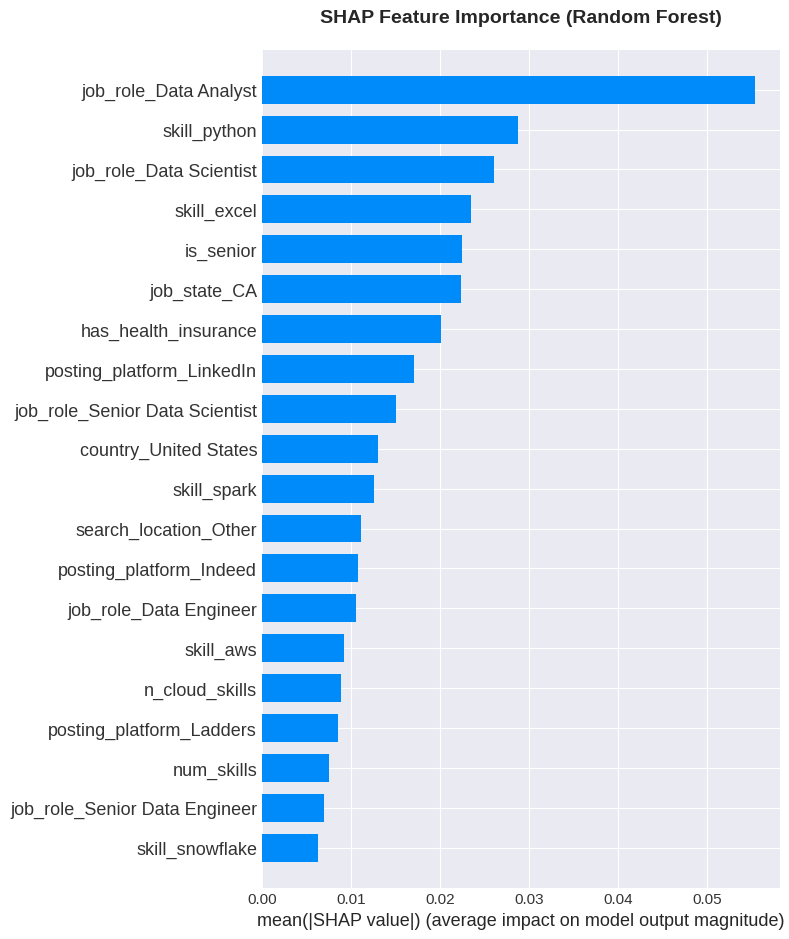

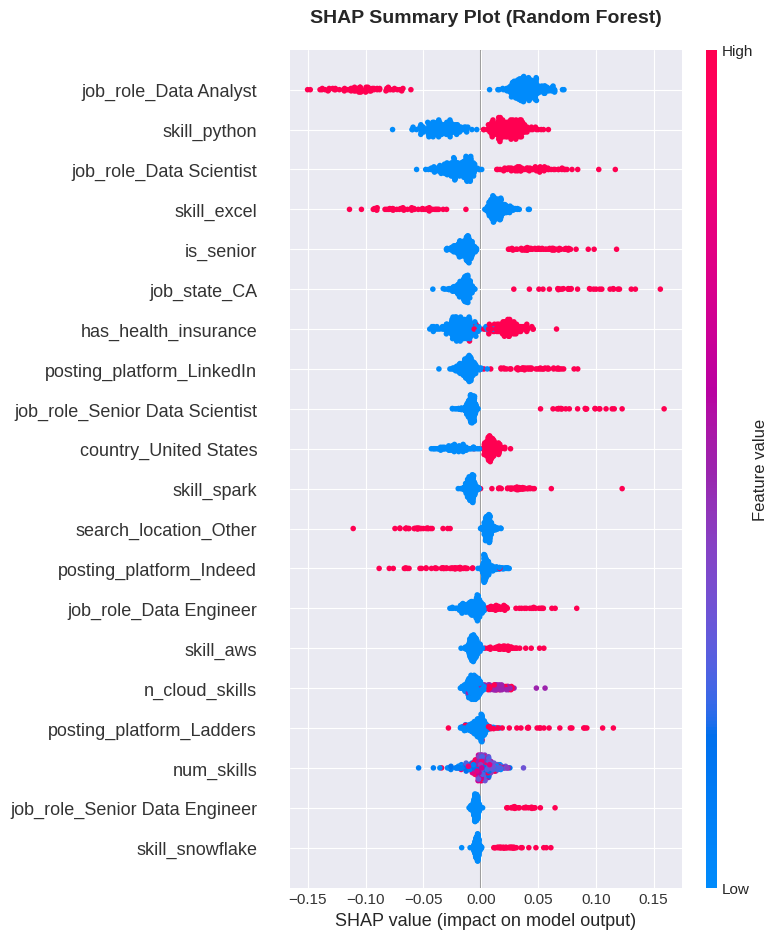


Top 20 Features by Mean |SHAP|:
                       Feature  Mean_Abs_SHAP
         job_role_Data Analyst       0.055398
                  skill_python       0.028692
       job_role_Data Scientist       0.026071
                   skill_excel       0.023418
                     is_senior       0.022417
                  job_state_CA       0.022347
          has_health_insurance       0.020156
     posting_platform_LinkedIn       0.017080
job_role_Senior Data Scientist       0.014999
         country_United States       0.013016
                   skill_spark       0.012587
         search_location_Other       0.011174
       posting_platform_Indeed       0.010765
        job_role_Data Engineer       0.010551
                     skill_aws       0.009243
                n_cloud_skills       0.008880
      posting_platform_Ladders       0.008511
                    num_skills       0.007509
 job_role_Senior Data Engineer       0.007006
               skill_snowflake       0.006305


In [ ]:
# SHAP Analysis
# Why this version is better:
# 1) Works whether best_model_obj is a fitted Pipeline or just the fitted estimator
# 2) Samples BEFORE explanation to make SHAP much faster
# 3) Uses TreeExplainer / LinearExplainer when possible
# 4) Avoids very slow full KernelExplainer on large data
# 5) Handles sparse transformed matrices safely

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from scipy import sparse
from sklearn.pipeline import Pipeline

print("Computing SHAP values...")

# 1. Resolve fitted preprocessor + fitted model
if isinstance(best_model_obj, Pipeline):
    fitted_preprocessor = best_model_obj.named_steps['preprocessor']
    fitted_model = best_model_obj.named_steps['model']
else:
    fitted_preprocessor = preprocessor
    fitted_model = best_model_obj

# 2. Sample test rows FIRST to reduce runtime
# You can increase/decrease these numbers depending on speed
N_EXPLAIN = min(300, len(X_test))      # rows to explain
N_BACKGROUND = min(100, len(X_test))   # background rows for non-tree explainers
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)
explain_idx = rng.choice(len(X_test), size=N_EXPLAIN, replace=False)
background_idx = rng.choice(len(X_test), size=N_BACKGROUND, replace=False)

# Keep data in original feature space first
if isinstance(X_test, pd.DataFrame):
    X_explain_raw = X_test.iloc[explain_idx].copy()
    X_background_raw = X_test.iloc[background_idx].copy()
else:
    X_explain_raw = X_test[explain_idx]
    X_background_raw = X_test[background_idx]

# 3. Transform only the needed rows
X_explain_transformed = fitted_preprocessor.transform(X_explain_raw)
X_background_transformed = fitted_preprocessor.transform(X_background_raw)
feature_names_out = fitted_preprocessor.get_feature_names_out()

# Convert sparse to dense only for the sampled rows used in SHAP plots
if sparse.issparse(X_explain_transformed):
    X_explain_plot = pd.DataFrame(
        X_explain_transformed.toarray(),
        columns=feature_names_out
    )
else:
    X_explain_plot = pd.DataFrame(X_explain_transformed, columns=feature_names_out)

if sparse.issparse(X_background_transformed):
    X_background_plot = pd.DataFrame(
        X_background_transformed.toarray(),
        columns=feature_names_out
    )
else:
    X_background_plot = pd.DataFrame(X_background_transformed, columns=feature_names_out)

# 4. Choose the fastest appropriate explainer
model_name = type(fitted_model).__name__.lower()

is_tree_model = any(name in model_name for name in [
    'xgb', 'lgbm', 'randomforest', 'extratrees', 'decisiontree',
    'gradientboosting', 'histgradientboosting', 'catboost'
]) or hasattr(fitted_model, 'estimators_')

is_linear_model = hasattr(fitted_model, 'coef_')

try:
    if is_tree_model:
        print(f"Using TreeExplainer for {type(fitted_model).__name__}...")
        explainer = shap.TreeExplainer(fitted_model)
        shap_values = explainer.shap_values(X_explain_plot)

    elif is_linear_model:
        print(f"Using LinearExplainer for {type(fitted_model).__name__}...")
        explainer = shap.LinearExplainer(fitted_model, X_background_plot)
        shap_values = explainer.shap_values(X_explain_plot)

    else:
        print(f"Using generic SHAP Explainer for {type(fitted_model).__name__}...")
        # Much safer and usually faster than large KernelExplainer usage
        explainer = shap.Explainer(fitted_model.predict, X_background_plot)
        shap_exp = explainer(X_explain_plot)
        shap_values = shap_exp.values

except Exception as e:
    print(f"Primary explainer failed: {e}")
    print("Falling back to small KernelExplainer sample...")

    # Tiny fallback only, to avoid notebook hanging
    X_bg_small = X_background_plot.iloc[:50].copy()
    X_explain_small = X_explain_plot.iloc[:100].copy()

    explainer = shap.KernelExplainer(fitted_model.predict, X_bg_small)
    shap_values = explainer.shap_values(X_explain_small)
    X_explain_plot = X_explain_small

# 5. Standardize SHAP output shape
# Some SHAP explainers return list-like or Explanation objects
if isinstance(shap_values, list):
    shap_values = shap_values[0]

if hasattr(shap_values, 'values'):
    shap_values = shap_values.values

shap_values = np.array(shap_values)

# In rare cases, binary/class outputs can add an extra dimension
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]

print(f"SHAP values computed for {len(X_explain_plot)} samples and {X_explain_plot.shape[1]} features")

# 6. Summary Bar Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_explain_plot,
    plot_type='bar',
    show=False,
    max_display=20
)
plt.title(f'SHAP Feature Importance ({best_name})', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 7. Beeswarm Plot
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values,
    X_explain_plot,
    show=False,
    max_display=20
)
plt.title(f'SHAP Summary Plot ({best_name})', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 8. SHAP importance table
# Make sure dimensions match before building the table
if shap_values.shape[1] == len(feature_names_out):
    shap_importance = pd.DataFrame({
        'Feature': feature_names_out,
        'Mean_Abs_SHAP': np.abs(shap_values).mean(axis=0)
    }).sort_values('Mean_Abs_SHAP', ascending=False)

    print("\nTop 20 Features by Mean |SHAP|:")
    print(shap_importance.head(20).to_string(index=False))
else:
    print("\nCould not build SHAP importance table because SHAP output shape did not match feature count.")
    print(f"SHAP shape: {shap_values.shape}, feature count: {len(feature_names_out)}")